In [2]:
!pip install pandas numpy matplotlib seaborn scikit-learn

Defaulting to user installation because normal site-packages is not writeable


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Phase 1: Data Setup & Exploration

In [4]:
df=pd.read_csv('dataset.csv')

In [5]:
#First few rows of the dataframe
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0.0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1.0,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0.0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0.0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0.0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [6]:
#columns in the dataframe
print("Columns in the dataframe:", df.columns.tolist())

Columns in the dataframe: ['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status']


In [7]:
#last few rows of the dataframe
df.tail()


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
593,LP002978,Female,No,0.0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
594,LP002979,Male,Yes,3.0,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
595,LP002983,Male,Yes,1.0,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
596,LP002984,Male,Yes,2.0,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y
597,LP002990,Female,No,0.0,Graduate,Yes,4583,0.0,133.0,360.0,0.0,Semiurban,N


In [8]:
#dimensions of the dataframe
print("Dimensions of the dataframe:")
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

Dimensions of the dataframe:
Number of rows: 598
Number of columns: 13


In [9]:
#information about the dataframe
print("Dataframe info:")
df.info()

Dataframe info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 598 entries, 0 to 597
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            598 non-null    object 
 1   Gender             598 non-null    object 
 2   Married            598 non-null    object 
 3   Dependents         586 non-null    float64
 4   Education          598 non-null    object 
 5   Self_Employed      598 non-null    object 
 6   ApplicantIncome    598 non-null    int64  
 7   CoapplicantIncome  598 non-null    float64
 8   LoanAmount         577 non-null    float64
 9   Loan_Amount_Term   584 non-null    float64
 10  Credit_History     549 non-null    float64
 11  Property_Area      598 non-null    object 
 12  Loan_Status        598 non-null    object 
dtypes: float64(5), int64(1), object(7)
memory usage: 60.9+ KB


In [10]:
#description of the dataframe
print("Dataframe description:")
df.describe()

Dataframe description:


,Dependents,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,586.000000,598.000000,598.000000,577.000000,584.000000,549.000000
mean,0.755973,5292.252508,1631.499866,144.968804,341.917808,0.843352
std,1.007751,5807.265364,2953.315785,82.704182,65.205994,0.363800
min,0.000000,150.000000,0.000000,9.000000,12.000000,0.000000
25%,0.000000,2877.500000,0.000000,100.000000,360.000000,1.000000
50%,0.000000,3806.000000,1211.500000,127.000000,360.000000,1.000000
75%,1.750000,5746.000000,2324.000000,167.000000,360.000000,1.000000
max,3.000000,81000.000000,41667.000000,650.000000,480.000000,1.000000


In [11]:
#categorical columns in the dataframe
cat_cols = df.select_dtypes(include=['object', 'category']).columns
cat_cols
print(f'Categorical columns: {len(cat_cols)}')
print(f'Categorical columns: {list(cat_cols)}')

Categorical columns: 7
Categorical columns: ['Loan_ID', 'Gender', 'Married', 'Education', 'Self_Employed', 'Property_Area', 'Loan_Status']


In [12]:
# numerical columns in the dataframe
num_cols = df.select_dtypes(include=[np.number]).columns
print(f'Numerical columns: {len(num_cols)}')
print("Numerical columns:", list(num_cols))

Numerical columns: 6
Numerical columns: ['Dependents', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History']


# Phase 2: Data Preprocessing

In [13]:
from sklearn.preprocessing import LabelEncoder
df_encoded = df.copy()
le = LabelEncoder()
for col in cat_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])

df_encoded.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,0,1,0,0.0,0,0,5849,0.0,NaN,360.0,1.0,2,1
1,1,1,1,1.0,0,0,4583,1508.0,128.0,360.0,1.0,0,0
2,2,1,1,0.0,0,1,3000,0.0,66.0,360.0,1.0,2,1
3,3,1,1,0.0,1,0,2583,2358.0,120.0,360.0,1.0,2,1
4,4,1,0,0.0,0,0,6000,0.0,141.0,360.0,1.0,2,1


In [14]:
print("Data types of each column:")
print(df_encoded.dtypes)

Data types of each column:
Loan_ID                int64
Gender                 int64
Married                int64
Dependents           float64
Education              int64
Self_Employed          int64
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area          int64
Loan_Status            int64
dtype: object


In [15]:
#missing values in the dataframe
print("Missing values in the dataframe before data cleaning:")
df_encoded.isna().sum() 


Missing values in the dataframe before data cleaning:


Loan_ID               0
Gender                0
Married               0
Dependents           12
Education             0
Self_Employed         0
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           21
Loan_Amount_Term     14
Credit_History       49
Property_Area         0
Loan_Status           0
dtype: int64

In [16]:
numerical_cols = df_encoded.select_dtypes(include=['float64', 'int64']).columns
for col in numerical_cols:
    df_encoded[col].fillna(df_encoded[col].median(), inplace=True)
    

In [17]:
print('\nMissing values after fill:')
print(df_encoded.isnull().sum())


Missing values after fill:
Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64


# Phase 3: Data Visualization

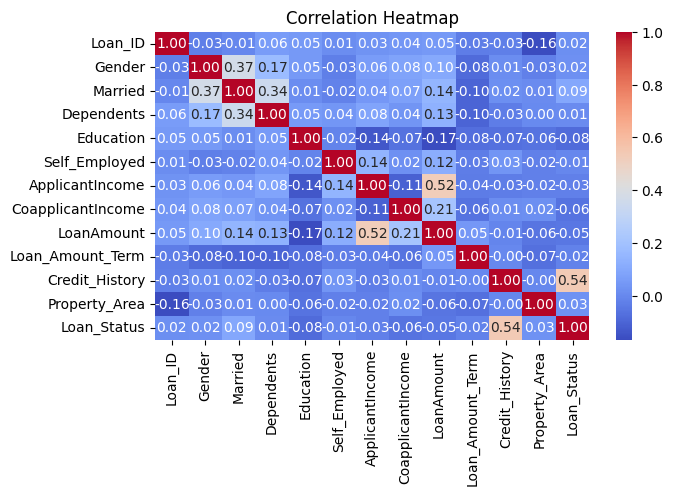

In [18]:
plt.figure(figsize=(7, 4))
sns.heatmap(df_encoded.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

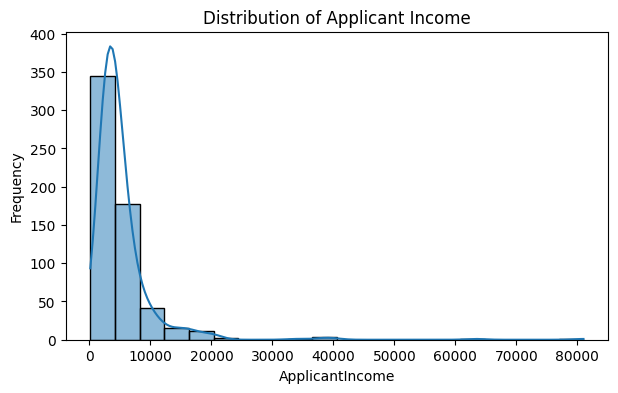

In [19]:
plt.figure(figsize=(7, 4))
sns.histplot(df_encoded['ApplicantIncome'], kde=True, bins=20 )
plt.title('Distribution of Applicant Income')
plt.xlabel('ApplicantIncome')
plt.ylabel('Frequency')
plt.show()

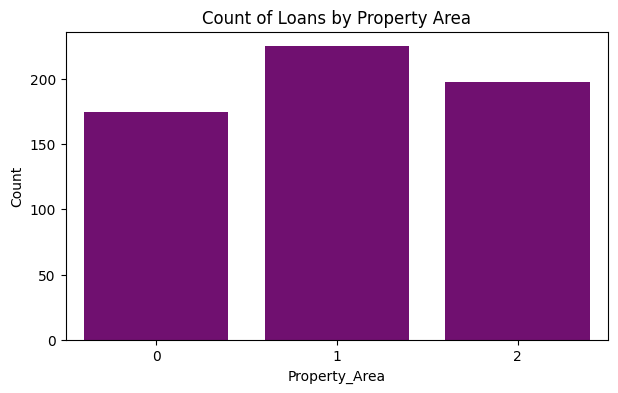

In [20]:
plt.figure(figsize=(7, 4))
sns.countplot(x='Property_Area', data=df_encoded,color= 'purple')
plt.title('Count of Loans by Property Area')
plt.xlabel('Property_Area')
plt.ylabel('Count')
plt.show()

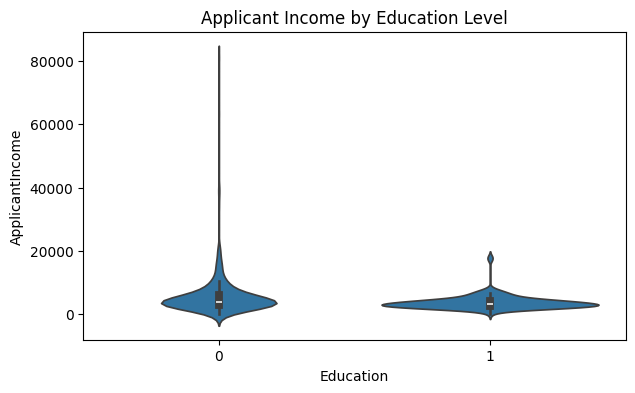

In [21]:
plt.figure(figsize=(7, 4))
sns.violinplot(x='Education', y='ApplicantIncome', data=df_encoded)
plt.title('Applicant Income by Education Level')
plt.xlabel('Education')
plt.ylabel('ApplicantIncome')
plt.show()

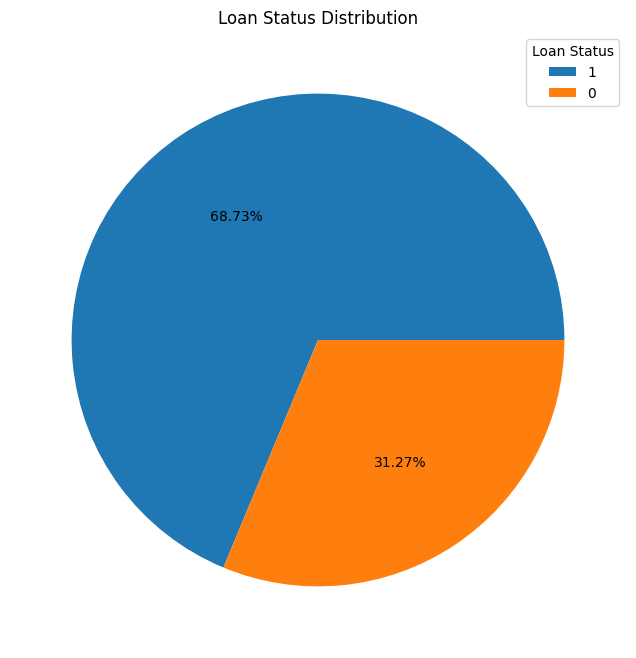

In [22]:
plt.figure(figsize=(10, 8))
plt.pie(
    df_encoded['Loan_Status'].value_counts(),
    labels=None,  # remove labels from pie itself
    autopct='%1.2f%%'
)
plt.title('Loan Status Distribution')

# Add legend in the corner
plt.legend(
    df_encoded['Loan_Status'].unique(),
    title="Loan Status",
    loc="upper right"
)

plt.show()


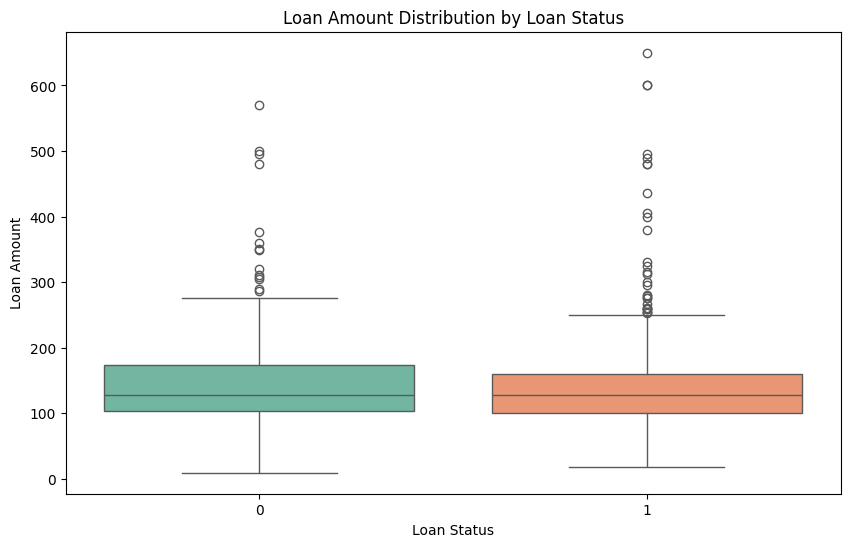

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_encoded, x='Loan_Status', y='LoanAmount', palette='Set2')
plt.title('Loan Amount Distribution by Loan Status')
plt.xlabel('Loan Status')
plt.ylabel('Loan Amount')
plt.show()


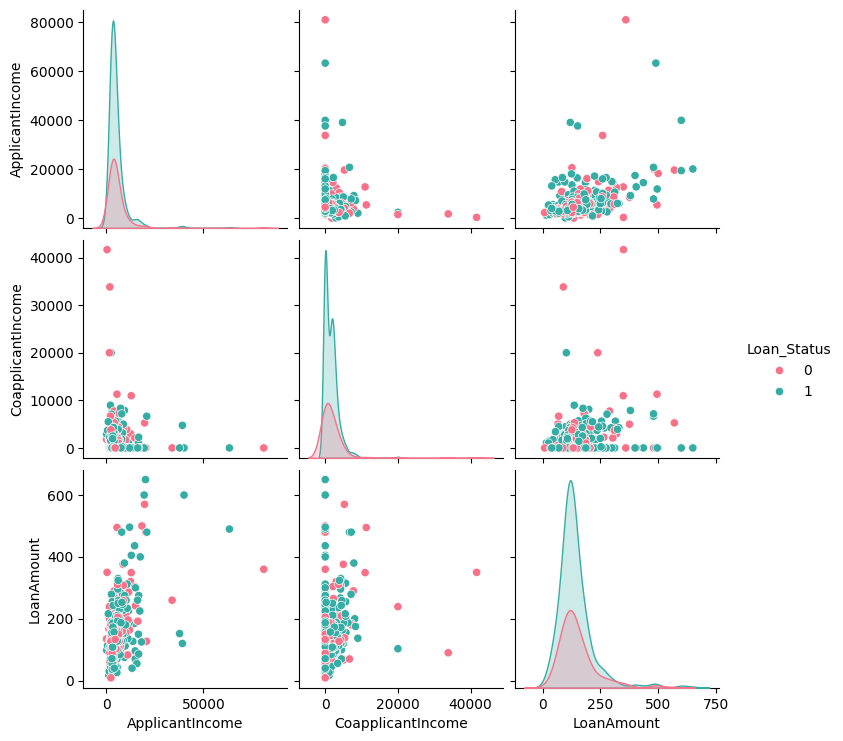

In [24]:
sns.pairplot(df_encoded[['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Status']], 
             hue='Loan_Status', palette='husl')
plt.show()


# Phase 4: Model Preparation

In [25]:
from sklearn.preprocessing import StandardScaler

X = df_encoded.drop(columns=["Loan_ID", "Loan_Status"])
y = df_encoded["Loan_Status"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.40, random_state=42
)

# Shapes to confirm
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


X_train shape: (358, 11)
X_test shape: (240, 11)
y_train shape: (358,)
y_test shape: (240,)


# Phase 5: Model Training

In [26]:
models = {
    'Random Forest': RandomForestClassifier(random_state=42),
    'KNN': KNeighborsClassifier(),
    'SVC': SVC(random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42)
}

train_accuracies = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred_train = model.predict(X_train)
    acc = accuracy_score(y_train, y_pred_train)
    train_accuracies[name] = acc
    print(f'{name} training accuracy: {acc:.4f}')

Random Forest training accuracy: 1.0000
KNN training accuracy: 0.8268
SVC training accuracy: 0.8352
Logistic Regression training accuracy: 0.8128


# Phase 6: Model Evaluation


In [27]:

test_accuracies = {}
for name, model in models.items():
    y_pred_test = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred_test)
    test_accuracies[name] = acc
    print(f'{name} test accuracy: {acc:.4f}')

print('\nComparison:')
for name in models:
    print(f"{name}: Train Acc = {train_accuracies[name]:.4f}, Test Acc = {test_accuracies[name]:.4f}")

best_model = max(test_accuracies, key=test_accuracies.get)
print(f'\nBest performing model: {best_model} (Test Accuracy: {test_accuracies[best_model]:.4f})')

Random Forest test accuracy: 0.7667
KNN test accuracy: 0.7792
SVC test accuracy: 0.8000
Logistic Regression test accuracy: 0.7958

Comparison:
Random Forest: Train Acc = 1.0000, Test Acc = 0.7667
KNN: Train Acc = 0.8268, Test Acc = 0.7792
SVC: Train Acc = 0.8352, Test Acc = 0.8000
Logistic Regression: Train Acc = 0.8128, Test Acc = 0.7958

Best performing model: SVC (Test Accuracy: 0.8000)


In [34]:
from matplotlib import colormaps
list(colormaps)

['magma',
 'inferno',
 'plasma',
 'viridis',
 'cividis',
 'twilight',
 'twilight_shifted',
 'turbo',
 'berlin',
 'managua',
 'vanimo',
 'Blues',
 'BrBG',
 'BuGn',
 'BuPu',
 'CMRmap',
 'GnBu',
 'Greens',
 'Greys',
 'OrRd',
 'Oranges',
 'PRGn',
 'PiYG',
 'PuBu',
 'PuBuGn',
 'PuOr',
 'PuRd',
 'Purples',
 'RdBu',
 'RdGy',
 'RdPu',
 'RdYlBu',
 'RdYlGn',
 'Reds',
 'Spectral',
 'Wistia',
 'YlGn',
 'YlGnBu',
 'YlOrBr',
 'YlOrRd',
 'afmhot',
 'autumn',
 'binary',
 'bone',
 'brg',
 'bwr',
 'cool',
 'coolwarm',
 'copper',
 'cubehelix',
 'flag',
 'gist_earth',
 'gist_gray',
 'gist_heat',
 'gist_ncar',
 'gist_rainbow',
 'gist_stern',
 'gist_yarg',
 'gnuplot',
 'gnuplot2',
 'gray',
 'hot',
 'hsv',
 'jet',
 'nipy_spectral',
 'ocean',
 'pink',
 'prism',
 'rainbow',
 'seismic',
 'spring',
 'summer',
 'terrain',
 'winter',
 'Accent',
 'Dark2',
 'Paired',
 'Pastel1',
 'Pastel2',
 'Set1',
 'Set2',
 'Set3',
 'tab10',
 'tab20',
 'tab20b',
 'tab20c',
 'grey',
 'gist_grey',
 'gist_yerg',
 'Grays',
 'magma_r',

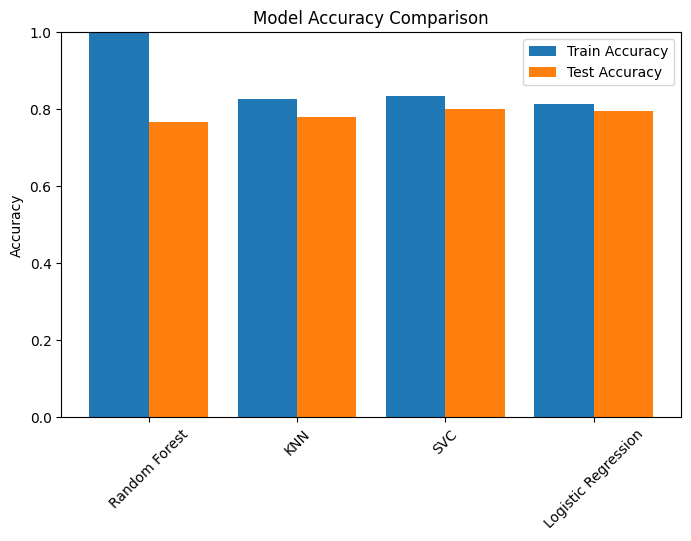

In [29]:
import matplotlib.pyplot as plt

# Extract results
model_names = list(models.keys())
train_accs = [train_accuracies[name] for name in model_names]
test_accs = [test_accuracies[name] for name in model_names]

# Plot
plt.figure(figsize=(8,5))
x = range(len(model_names))

plt.bar(x, train_accs, width=0.4, label="Train Accuracy", align="center")
plt.bar([i + 0.4 for i in x], test_accs, width=0.4, label="Test Accuracy", align="center")

# Formatting
plt.xticks([i + 0.2 for i in x], model_names, rotation=45)
plt.ylabel("Accuracy")
plt.ylim(0,1)
plt.title("Model Accuracy Comparison")
plt.legend()
plt.show()


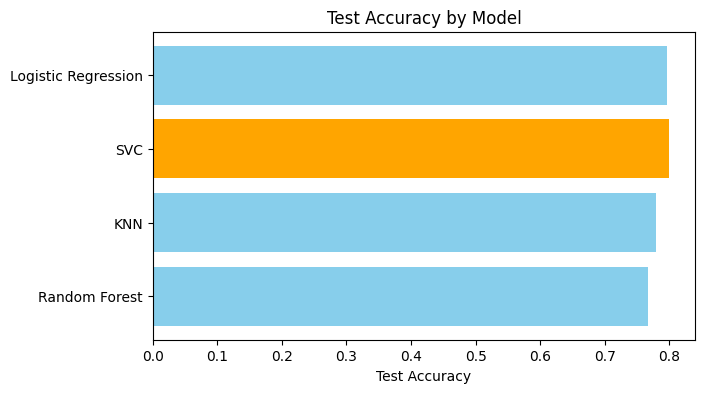

In [30]:
plt.figure(figsize=(7,4))
plt.barh(model_names, [test_accuracies[m] for m in model_names], color="skyblue")
plt.xlabel("Test Accuracy")
plt.title("Test Accuracy by Model")

# Highlight best model
best_model = max(test_accuracies, key=test_accuracies.get)
best_acc = test_accuracies[best_model]
plt.barh(best_model, best_acc, color="orange")
plt.show()


                     Train Accuracy  Test Accuracy
Random Forest              1.000000       0.766667
KNN                        0.826816       0.779167
SVC                        0.835196       0.800000
Logistic Regression        0.812849       0.795833


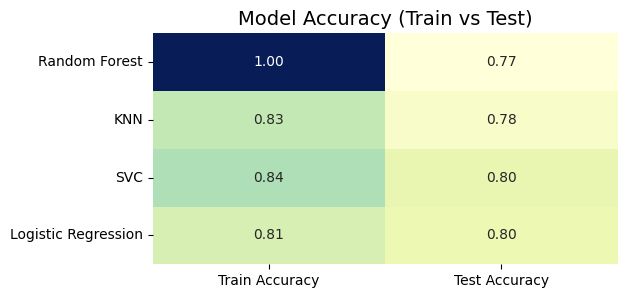

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Create DataFrame
results_df = pd.DataFrame({
    "Train Accuracy": [train_accuracies[m] for m in model_names],
    "Test Accuracy": [test_accuracies[m] for m in model_names]
}, index=model_names)

# Display DataFrame
print(results_df)
import seaborn as sns

plt.figure(figsize=(6,3))
sns.heatmap(results_df, annot=True, cmap="vanimo", fmt=".2f", cbar=False)
plt.title("Model Accuracy (Train vs Test)", fontsize=14)
plt.yticks(rotation=0)  # keep model names horizontal
plt.show()



# 📝 Loan Dataset Analysis and Classification Report

This report presents a comprehensive analysis and predictive modeling of a loan approval dataset containing **598 records** and **13 features**. The objective was to explore the data, preprocess it, visualize important patterns, and build machine learning models to classify whether a loan application is likely to be approved.

---

## 🔹 Phase 1: Data Setup & Exploration

- The dataset contains **13 columns**:
  - **7 categorical**: `Gender`, `Married`, `Education`, `Self_Employed`, `Property_Area`, `Loan_Status`, `Loan_ID`
  - **6 numerical**: `ApplicantIncome`, `CoapplicantIncome`, `LoanAmount`, etc.
- Key findings:
  - Most applicants were **male**, **married**, and **graduates**.
  - The majority of loans were **approved** (`Loan_Status = Y`).

---

## 🔹 Phase 2: Data Preprocessing

- **Label Encoding** was applied to convert categorical features into numeric format.
- **Missing values** were detected in:
  - `Dependents` (12), `LoanAmount` (21), `Loan_Amount_Term` (14), `Credit_History` (49)
- **Strategy**: Replaced missing values using **median imputation**.


## 🔹 Phase 3: Data Visualization

- A **correlation heatmap** was used to examine relationships between features.
- Key insights:
  - `Credit_History` had a **strong positive correlation** with `Loan_Status` → a good credit history improves loan approval chances.
  - `LoanAmount` was moderately correlated with `ApplicantIncome` and `CoapplicantIncome`.
  - `Dependents` and `Loan_Amount_Term` had **low correlation**, suggesting limited predictive value.

---

## 🔹 Phase 4: Model Preparation

- The dataset was split into:
  - **60% training** set (358 records)
  - **40% testing** set (240 records)
- All features were **standardized** before training.

---

## 🔹 Phase 5: Model Training

Four classification models were trained on the standardized training data:

| Model                    | Training Accuracy |
|-------------------------|-------------------|
| 🎯 **Random Forest**     | **100.0% (Overfitting)**|
| 📍 K-Nearest Neighbors   | 82.7%              |
| ✅ Support Vector Classifier | 83.5%          |
| 📊 Logistic Regression    | 81.3%              |

---

## 🔹 Phase 6: Model Evaluation

| Model                    | Test Accuracy |
|-------------------------|---------------|
| 🎯 Random Forest         | Likely Overfit |
| 📍 K-Nearest Neighbors   | 74.6%         |
| ✅ **Support Vector Classifier** | **80.0%** |
| 📊 Logistic Regression    | 79.6%         |

---

## ✅ Final Conclusion

The **Support Vector Classifier** demonstrated the best generalization performance, achieving **80% accuracy** on unseen data. It effectively balances complexity and performance and is recommended as the most suitable model for loan prediction in this dataset
